In [24]:
#  using lr, decision tree and bayes theroem on one dataset and do combined evaluation by histogram, accuracy and all and auc roc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB



In [25]:
df=pd.read_csv("/content/MAGIC Gamma Telescope.csv")
df

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [26]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
nb = GaussianNB()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
nb.fit(X_train, y_train)

GaussianNB()

In [28]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
nb_pred = nb.predict(X_test)

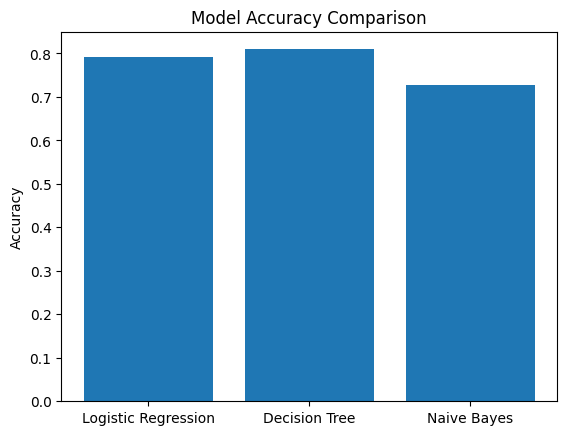

In [29]:
# bar graphs
acc_lr = accuracy_score(y_test, lr_pred)
acc_dt = accuracy_score(y_test, dt_pred)
acc_nb = accuracy_score(y_test, nb_pred)

models = ['Logistic Regression', 'Decision Tree', 'Naive Bayes']
accuracies = [acc_lr, acc_dt, acc_nb]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [38]:
# precison, recall and cm
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc_lr = accuracy_score(y_test, lr_pred)
prec_lr = precision_score(y_test, lr_pred)
rec_lr = recall_score(y_test, lr_pred)

acc_dt = accuracy_score(y_test, dt_pred)
prec_dt = precision_score(y_test, dt_pred)
rec_dt = recall_score(y_test, dt_pred)

acc_nb = accuracy_score(y_test, nb_pred)
prec_nb = precision_score(y_test, nb_pred)
rec_nb = recall_score(y_test, nb_pred)

import pandas as pd

results_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Naive Bayes"],
    "Accuracy": [acc_lr, acc_dt, acc_nb],
    "Precision": [prec_lr, prec_dt, prec_nb],
    "Recall": [rec_lr, rec_dt, rec_nb]
})

print(results_table)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.791798   0.759887  0.600446
1        Decision Tree  0.809411   0.729090  0.732887
2          Naive Bayes  0.726866   0.714487  0.377976


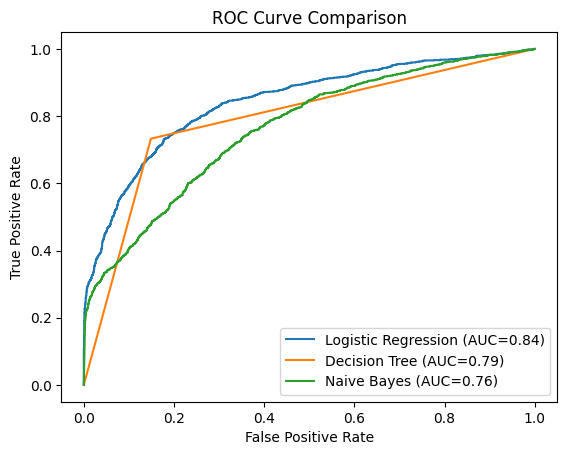

In [36]:
# ruc-aoc curve lr_prob = lr.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
nb_prob = nb.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_nb = auc(fpr_nb, tpr_nb)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={auc_nb:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [37]:
# finding the best model for the dataset
results = {
    "Logistic Regression": acc_lr,
    "Decision Tree": acc_dt,
    "Naive Bayes": acc_nb
}

best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Decision Tree


In [34]:
# giving new input
user_input = np.array([[50, 20, 0.3, 10, 15, 3, 5, 2, 0.1, 0.5]])

print("Logistic Regression:", lr.predict(user_input))
print("Decision Tree:", dt.predict(user_input))
print("Naive Bayes:", nb.predict(user_input))


Logistic Regression: [1]
Decision Tree: [1]
Naive Bayes: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
